Data understanding 
## Objective 
understanding the data before training the model

We will examine:
- Dataset size (Rows and Columns in the dataset)
- Features
- Data types
- Missing values
- Duplicate records
- Class distribution
- Initial observations

In [ ]:
import pandas as pd

df = pd.read_csv("../data/raw/creditcard.csv")

In [ ]:
df.shape

### Observation
- The above output tells us that the dataset contains 284,807 rows and 31 columns.
- That means the dataset has data of **284,807 transactions**.
- This is a sufficiently large dataset for building a machine learning model.

In [ ]:
df.columns

### Observation
The dataset contains:

- Time
- 28 anonymized features (V1–V28)
- Amount
- Class (Target Variable)

In [ ]:
df.head()

Quick look of the dataset 

In [ ]:
df.info()

### Observation
The above tells us some basic information like number of rows and columns and also
Data types and Missing values


## Checking for missing values

In [ ]:
df.isnull().sum()

## Observation
- The dataset contains no missing values i.e. no missing values in any column 
- No missing value imputation needed

## Checking for dublicate records 
we need to check if our dataset contains dublicate values 

In [37]:
df.duplicated().sum()

np.int64(1081)

### Observation
- The dataset contains duplicate transactions.
- These duplicates may influence the learning process.

## Class Distribution

The target variable is **Class**, where:

- **0** represents a legitimate transaction.
- **1** represents a fraudulent transaction.

In [38]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

## Inference
This means there are 
284315 legitimate transactions 
492 fraud transactions 
That is less then **0.2%**

- The dataset is **highly imbalanced** 

## VISUALIZING

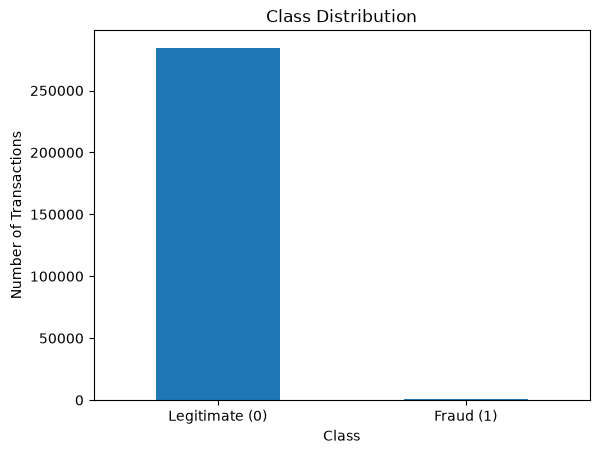

In [ ]:
import matplotlib.pyplot as plt

class_counts = df["Class"].value_counts()

class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate (0)", "Fraud (1)"], rotation=0)

plt.show()

### Observation

- The dataset is highly imbalanced.
- Legitimate transactions vastly outnumber fraudulent transactions.
- The fraud class appears almost invisible in the bar chart because it represents only a tiny fraction of all transactions.
- This imbalance means that accuracy alone will not be a reliable for evaluating our machine learning model.

## Statistical summary 

In [40]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


### Observation

- The dataset contains numerical features.
- The `Amount` feature has a wide range of transaction values.
- The anonymized features (V1–V28) appear to be standardized.

In [41]:
(df["Class"].value_counts(normalize=True) * 100).round(2)

Class
0    99.83
1     0.17
Name: proportion, dtype: float64

### Observation

- Approximately 99.83% of transactions are legitimate.
- Approximately 0.17% of transactions are fraudulent.
- This confirms that the dataset is highly imbalanced.

# Final Observations

- The dataset contains 284,807 transactions.
- There are 31 features.
- No missing values are present.
- Duplicate records exist and will be handled during preprocessing.
- The dataset is highly imbalanced.
- The target variable is `Class`.
- Data is ready for Exploratory Data Analysis (EDA).